# TP2

## Implementar un detector de maximo enfoque sobre un video aplicando tecnicas de analisis espectral similar al que utilizan las camaras digitales modernas. El video a procesar sera: "focus_video.mov".

Se debe implementar un algoritmo que dada una imagen, o region, calcule la metrica propuesta en el paper "Image Sharpness MEasure for Blurred Images in Frequency Domain" y realizar dos experimentos:

1 Medicion sobre el frame

2 Medicion sobre una ROI ubicada en el centro del fame. Area de la ROI = 5 o 10% del area total del frame.

Para cada experimento se debe presentar:
Una o varias curvas que muestren la evolucion de la metrica frame a frame donde se vea claramente como el algoritmo detecto la region de maximo enfoque.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [27]:
def image_quality_measure(image):
    gray = np.asarray(image, dtype=np.float32)
    if gray.ndim != 2 or gray.size == 0:
        raise ValueError("La entrada debe ser una imagen gris no vacia")
    # Step 1: Compute F which is the Fourier Transform representation of image I  
    img_f = np.fft.fft2(gray)
    # Step 2:  Find Fc which is obtained by shifting the origin of F to centre.
    img_fc = np.fft.fftshift(img_f)
    # Step 3: Calculate AF = abs (Fc) where AF is the absolute value of the centered Fourier transform of image I
    #img_af = 20*np.log(np.abs(img_fc))
    img_af = np.abs(img_fc)
    # Step 4:  Calculate M = max (AF) where M is the maximum value of the frequency component in F.
    M = np.max(img_af)
    # Step 5: Calculate TH = the total number of pixels in F whose pixel value > thres, where thres = M/1000
    thres = M / 1000
    TH = np.sum(img_af > thres)
    # Step 6: Calculate Image Quality measure (FM) from equation
    print(f"TH: {TH}, Total pixels: {image.shape[0] * image.shape[1]}, M: {M}, Threshold: {thres}") 
    return (TH / (image.shape[0] * image.shape[1]))

def roi_central_nueva(frame_gray, area_fraction=ROI_AREA_NUEVO):
    """Devuelve una ROI central cuya area es aproximadamente area_fraction."""
    height, width = frame_gray.shape
    scale = np.sqrt(area_fraction)
    roi_height = max(1, round(height * scale))
    roi_width = max(1, round(width * scale))
    top = (height - roi_height) // 2
    left = (width - roi_width) // 2
    roi = frame_gray[top:top + roi_height, left:left + roi_width]
    return roi, (left, top, roi_width, roi_height)

In [28]:
# Abre el video
video_path = 'focus_video.mov'
captura_video = cv2.VideoCapture(video_path)

ROI = 0.10  # 10% del área de la imagen
measures = []
measures_roi = []

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    # Obtén las dimensiones del video
    frame_width = int(captura_video.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(captura_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Obtén la tasa de cuadros (frame rate) del video
    fps = int(captura_video.get(cv2.CAP_PROP_FPS))
    #fps = 35
    delay = int(600 / fps)
    
    while True:
        ret, frame = captura_video.read()
        if not ret or frame is None:
            break

        # Procesamiento básico: convertir a escala de grises
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_resized = cv2.resize(frame_gris, (int(frame_width * ROI), int(frame_height * ROI)))

        quality_gris = image_quality_measure(frame_gris)
        quality_resized = image_quality_measure(frame_resized)

        measures.append(quality_gris)
        measures_roi.append(quality_resized)
        # Salir del loop si se presiona la tecla 'q'
        if cv2.waitKey(delay) & 0xFF == ord('q'):
            break

# Libera el objeto de captura de video y cierra todas las ventanas
captura_video.release()
cv2.destroyAllWindows()

TH: 1641, Total pixels: 230400, M: 12025545.0, Threshold: 12025.544921875
TH: 1342, Total pixels: 2304, M: 120587.0, Threshold: 120.58699798583984
TH: 1645, Total pixels: 230400, M: 12028444.0, Threshold: 12028.4443359375
TH: 1378, Total pixels: 2304, M: 120608.0, Threshold: 120.60800170898438
TH: 1643, Total pixels: 230400, M: 11987121.0, Threshold: 11987.12109375
TH: 1374, Total pixels: 2304, M: 120200.0, Threshold: 120.19999694824219
TH: 1635, Total pixels: 230400, M: 11994329.0, Threshold: 11994.3291015625
TH: 1394, Total pixels: 2304, M: 120242.0, Threshold: 120.24199676513672
TH: 1617, Total pixels: 230400, M: 11953043.0, Threshold: 11953.04296875
TH: 1406, Total pixels: 2304, M: 119802.0, Threshold: 119.802001953125
TH: 1609, Total pixels: 230400, M: 11936945.0, Threshold: 11936.9453125
TH: 1414, Total pixels: 2304, M: 119594.0, Threshold: 119.59400177001953
TH: 1609, Total pixels: 230400, M: 11891819.0, Threshold: 11891.8193359375
TH: 1418, Total pixels: 2304, M: 119192.0, Thre

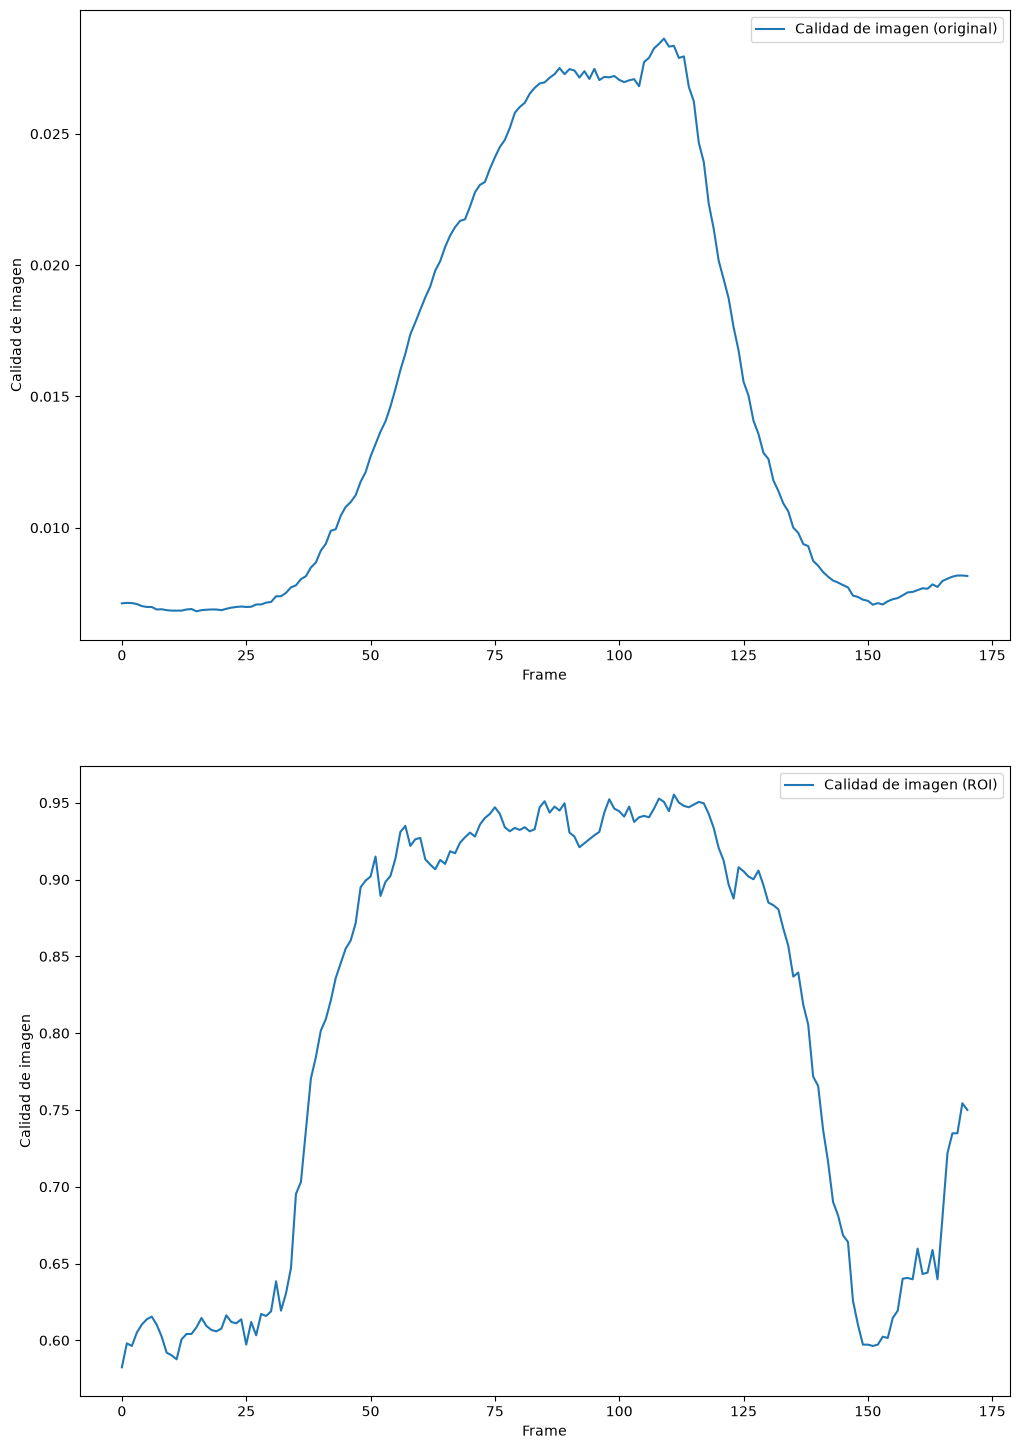

In [29]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 18))

plt.subplot(2, 1, 1)
plt.plot(measures, label='Calidad de imagen (original)')
plt.xlabel('Frame')
plt.ylabel('Calidad de imagen')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(measures_roi, label='Calidad de imagen (ROI)')
plt.xlabel('Frame')
plt.ylabel('Calidad de imagen')
plt.legend()

plt.show()


In [25]:
captura_nueva = cv2.VideoCapture(VIDEO_PATH_NUEVO)
if not captura_nueva.isOpened():
    raise FileNotFoundError(f"No se pudo abrir el video: {VIDEO_PATH_NUEVO}")

medidas_frame_nuevas = []
medidas_roi_nuevas = []
primer_frame_nuevo = None
caja_roi_nueva = None

while True:
    ok, frame = captura_nueva.read()
    if not ok:
        break

    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi, caja_actual = extraer_roi_central_nueva(gris)

    medidas_frame_nuevas.append(medida_ism_nueva(gris))
    medidas_roi_nuevas.append(medida_ism_nueva(roi))

    if primer_frame_nuevo is None:
        primer_frame_nuevo = gris
        caja_roi_nueva = caja_actual

fps_nuevo = captura_nueva.get(cv2.CAP_PROP_FPS)
captura_nueva.release()

if not medidas_frame_nuevas:
    raise ValueError("No se encontraron frames validos en el video")

medidas_frame_nuevas = np.asarray(medidas_frame_nuevas)
medidas_roi_nuevas = np.asarray(medidas_roi_nuevas)
frame_maximo_nuevo = int(np.argmax(medidas_frame_nuevas))
frame_maximo_roi_nuevo = int(np.argmax(medidas_roi_nuevas))

_, _, roi_width_nueva, roi_height_nueva = caja_roi_nueva
area_relativa_nueva = roi_width_nueva * roi_height_nueva / primer_frame_nuevo.size
print(f"Frames procesados: {len(medidas_frame_nuevas)}")
print(f"FPS: {fps_nuevo:.2f}")
print(f"ROI central: {roi_width_nueva} x {roi_height_nueva} px")
print(f"Area relativa de la ROI: {area_relativa_nueva:.2%}")
print(f"Maximo frame completo: frame {frame_maximo_nuevo}, medida {medidas_frame_nuevas[frame_maximo_nuevo]:.6f}")
print(f"Maximo ROI central: frame {frame_maximo_roi_nuevo}, medida {medidas_roi_nuevas[frame_maximo_roi_nuevo]:.6f}")

Frames procesados: 171
FPS: 29.97
ROI central: 202 x 114 px
Area relativa de la ROI: 9.99%
Maximo frame completo: frame 109, medida 0.028624
Maximo ROI central: frame 111, medida 0.359389


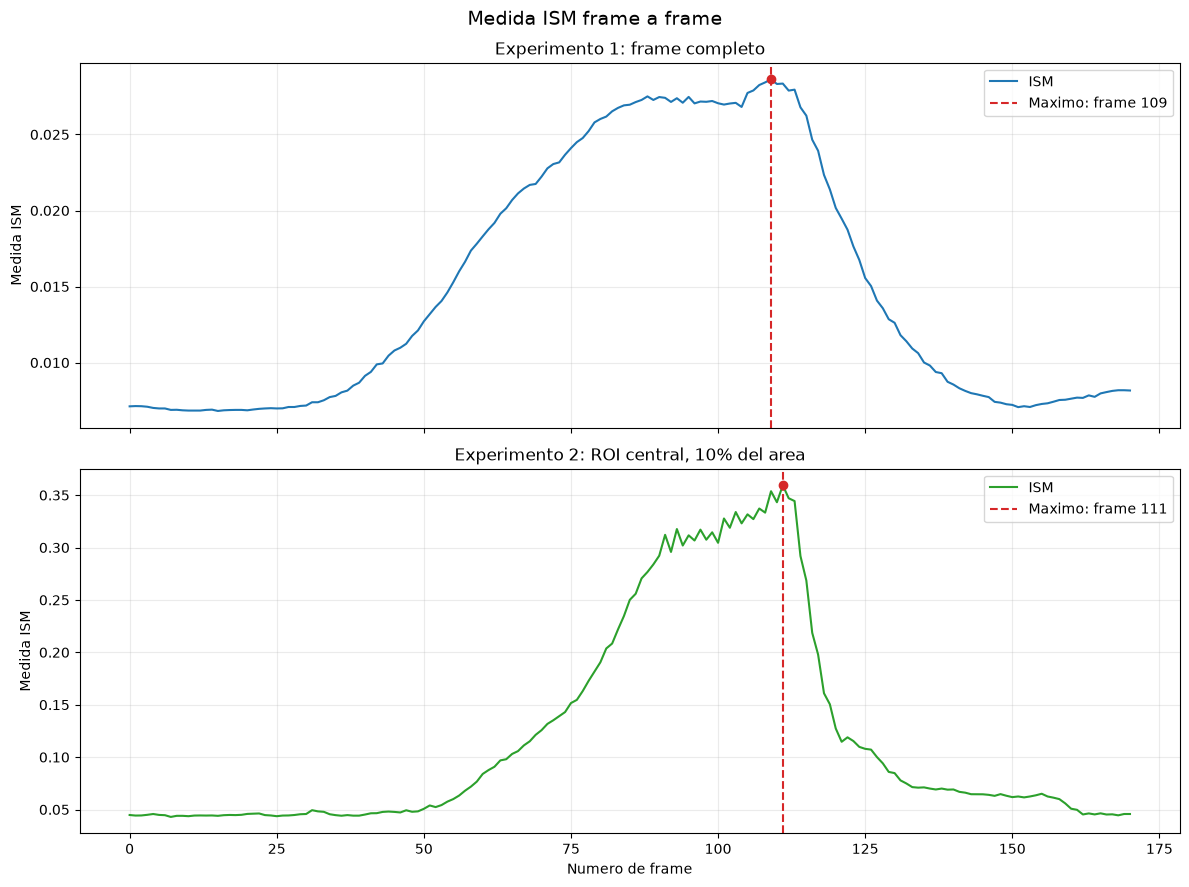

In [30]:
frames_nuevos = np.arange(len(medidas_frame_nuevas))

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Medida ISM frame a frame", fontsize=14)

axes[0].plot(frames_nuevos, medidas_frame_nuevas, color="tab:blue")
axes[0].axvline(frame_maximo_nuevo, color="tab:red", linestyle="--")
axes[0].scatter(frame_maximo_nuevo, medidas_frame_nuevas[frame_maximo_nuevo], color="tab:red", zorder=3)
axes[0].set_title("Experimento 1: frame completo")
axes[0].set_ylabel("Medida ISM")
axes[0].legend(["ISM", f"Maximo: frame {frame_maximo_nuevo}"])
axes[0].grid(alpha=0.25)

axes[1].plot(frames_nuevos, medidas_roi_nuevas, color="tab:green")
axes[1].axvline(frame_maximo_roi_nuevo, color="tab:red", linestyle="--")
axes[1].scatter(frame_maximo_roi_nuevo, medidas_roi_nuevas[frame_maximo_roi_nuevo], color="tab:red", zorder=3)
axes[1].set_title("Experimento 2: ROI central, 10% del area")
axes[1].set_xlabel("Numero de frame")
axes[1].set_ylabel("Medida ISM")
axes[1].legend(["ISM", f"Maximo: frame {frame_maximo_roi_nuevo}"])
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
# Verificacion visual de la ROI central utilizada.
left, top, roi_width_nueva, roi_height_nueva = caja_roi_nueva
preview_nuevo = cv2.cvtColor(primer_frame_nuevo, cv2.COLOR_GRAY2RGB)
cv2.rectangle(
    preview_nuevo,
    (left, top),
    (left + roi_width_nueva, top + roi_height_nueva),
    (255, 0, 0),
    2,
)
plt.figure(figsize=(8, 5))
plt.imshow(preview_nuevo)
plt.title("ROI central utilizada")
plt.axis("off")
plt.show()

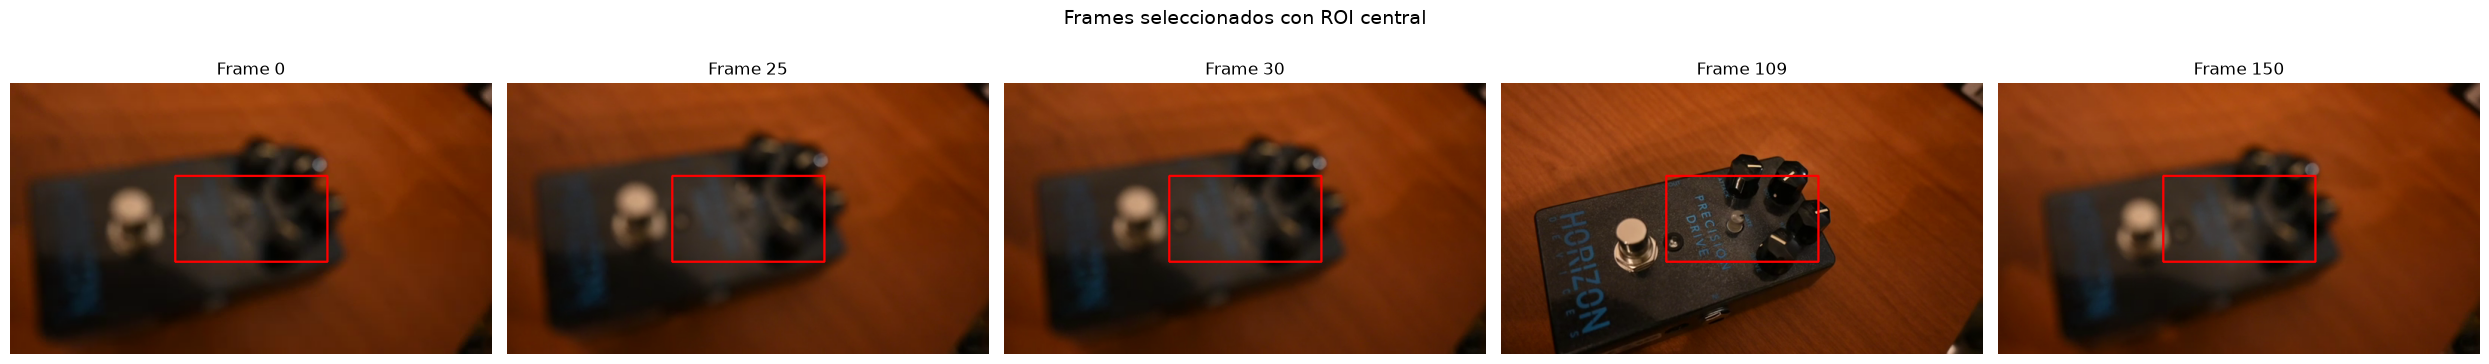

Frames mostrados: [0, 25, 30, 109, 150]


In [38]:
# Mostrar las imagenes de los frames solicitados con la ROI central.
frames_a_mostrar = sorted(set([0, 25, 30, frame_maximo_nuevo, 150]))
captura_frames = cv2.VideoCapture(VIDEO_PATH_NUEVO)

if not captura_frames.isOpened():
    raise FileNotFoundError(f"No se pudo abrir el video: {VIDEO_PATH_NUEVO}")

frames_encontrados = {}
indice_frame = 0

while True:
    ok, frame = captura_frames.read()
    if not ok:
        break

    if indice_frame in frames_a_mostrar:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        izquierda, arriba, ancho_roi, alto_roi = caja_roi_nueva
        cv2.rectangle(
            frame_rgb,
            (izquierda, arriba),
            (izquierda + ancho_roi, arriba + alto_roi),
            (255, 0, 0),
            2,
        )
        frames_encontrados[indice_frame] = frame_rgb

    if len(frames_encontrados) == len(frames_a_mostrar):
        break

    indice_frame += 1

captura_frames.release()

cantidad = len(frames_encontrados)
fig, axes = plt.subplots(1, cantidad, figsize=(5 * cantidad, 4))
if cantidad == 1:
    axes = [axes]

for axis, numero_frame in zip(axes, frames_a_mostrar):
    axis.imshow(frames_encontrados[numero_frame])
    axis.set_title(f"Frame {numero_frame}")
    axis.axis("off")

fig.suptitle("Frames seleccionados con ROI central", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Frames mostrados: {sorted(frames_encontrados.keys())}")